# Lennard–Jones Dynamics, Heating, and Melting

Periodic boundaries and Verlet integration, energy and temperature tracking, particle displacement, staged heating, and comparisons between initial conditions.

Computational physics coursework by Udayan Sharma. Original code comments and saved outputs are retained. See the repository README for execution notes.


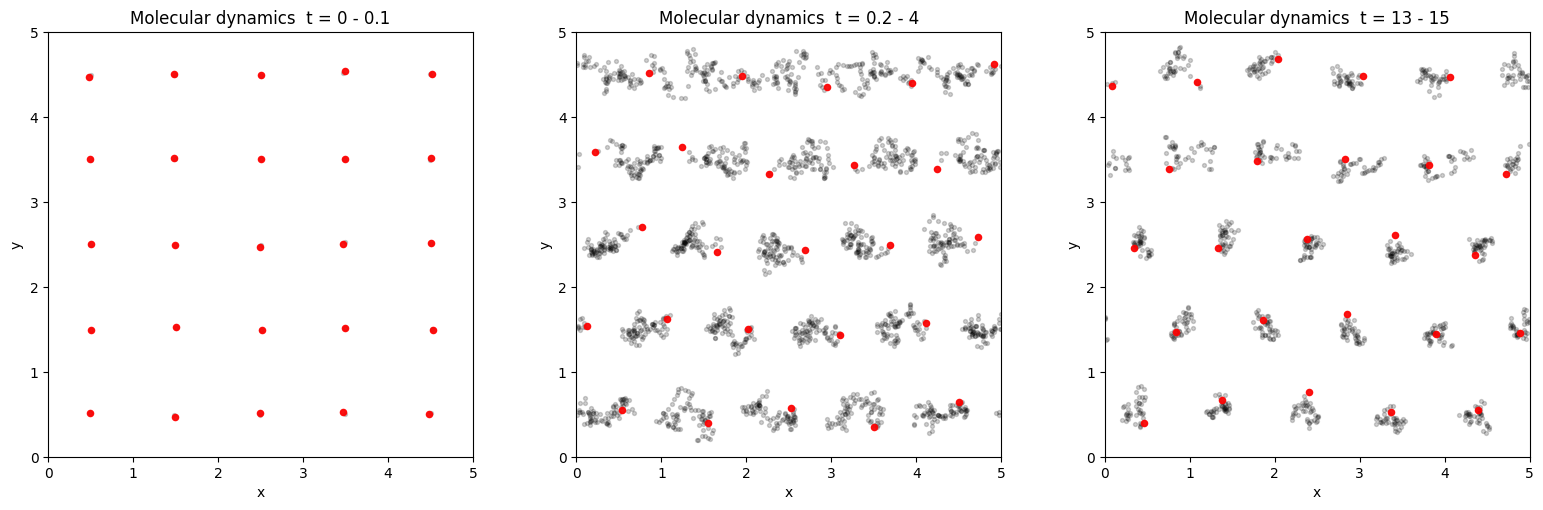

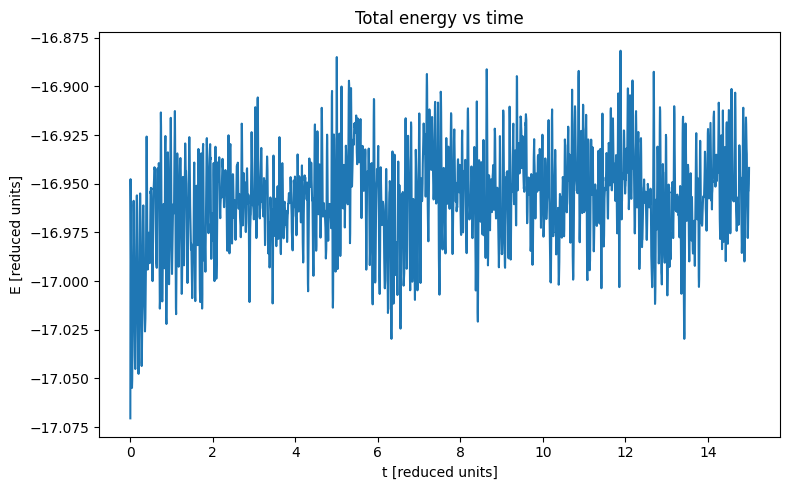

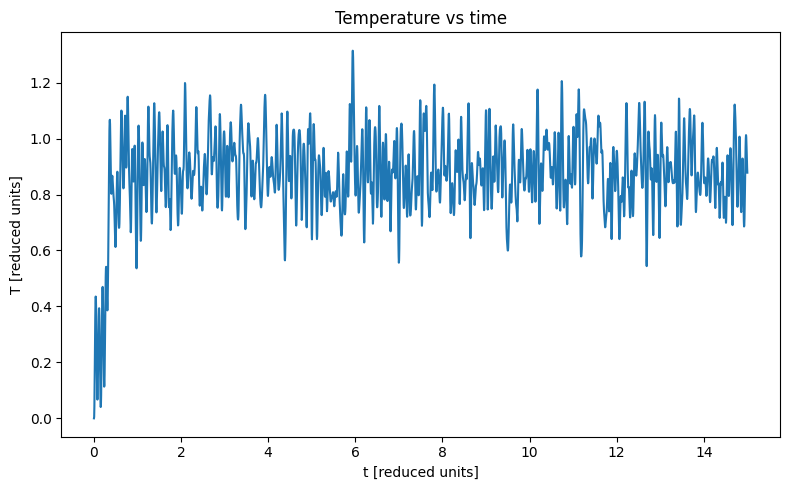

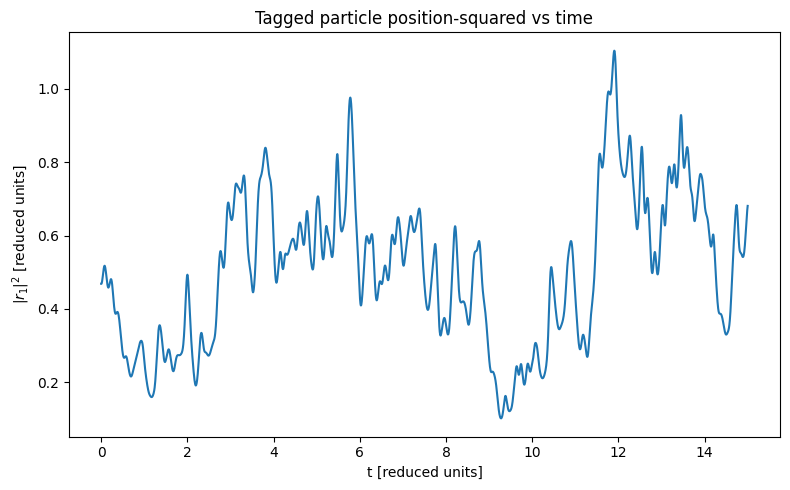

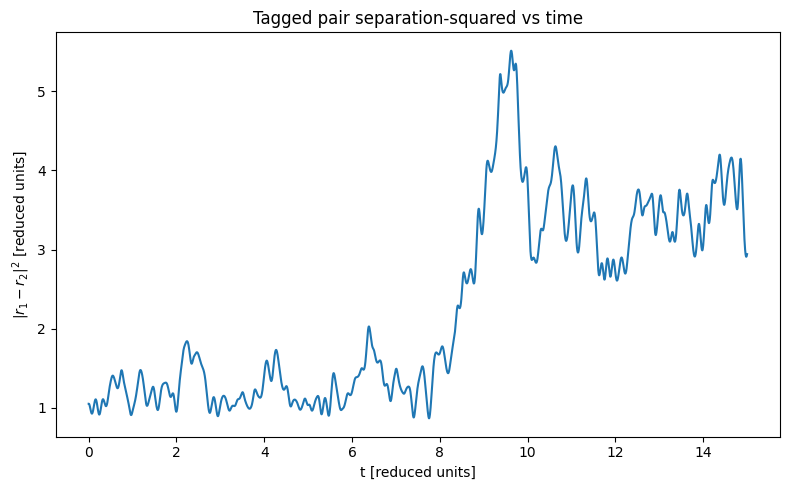

Final time = 15.000
Initial energy = -17.070519
Final energy   = -16.941846
Mean temperature = 0.874528
Final tagged pair separation^2 = 2.942043


In [ ]:
# Lab 12 - Task 1

import numpy as np;
import matplotlib.pyplot as plt;

# Parameters for Task 1
N = 25;
L = 5.0;
dt = 0.005;
tmax = 15.0;
rcut = 3.0;
dmax = 0.05;
snapshot_windows = [(0.0, 0.1), (0.2, 4.0), (13.0, 15.0)];
record_every = 10;
rng = np.random.default_rng(12345);

# Wrap positions into [0, L)
def wrap_positions(r, L):
    return r % L;

# Minimum-image convention for a coordinate difference
def minimum_image(dx, L):
    return dx - L * np.round(dx / L);

# Minimum-image displacement using wrapped positions. Used for forces and PBC-aware pair separations.
def pair_displacement_wrapped(ri_wrap, rj_wrap, L):
    dx = minimum_image(ri_wrap[0] - rj_wrap[0], L);
    dy = minimum_image(ri_wrap[1] - rj_wrap[1], L);
    return dx, dy;

# Place particles on a square grid plus small random shifts
def initialize_system(N, L, dmax, dt, rng):
    r = np.zeros((N, 2), dtype = float);
    rprev = np.zeros((N, 2), dtype = float);
    Ngrid = int(np.ceil(np.sqrt(N)));
    Lgrid = L / Ngrid;

    for k in range(N):
        i = k // Ngrid;
        j = k % Ngrid;
        r[k, 0] = (i + 0.5) * Lgrid + (rng.random() - 0.5) * dmax * Lgrid * np.sqrt(2.0);
        r[k, 1] = (j + 0.5) * Lgrid + (rng.random() - 0.5) * dmax * Lgrid * np.sqrt(2.0);
    #endfor

    # initially at rest
    rprev[:] = r;
    return r, rprev;

# Compute total forces using wrapped positions and minimum-image convention
def compute_forces_from_wrapped(r_wrap, N, L, rcut):
    F = np.zeros((N, 2), dtype = float);
    rcut2 = rcut * rcut;

    for i in range(N):
        for j in range(i):
            dx, dy = pair_displacement_wrapped(r_wrap[i], r_wrap[j], L)
            rij2 = dx * dx + dy * dy;
            if rij2 == 0.0 or rij2 > rcut2:
                continue;

            invr2 = 1.0 / rij2;
            invr6 = invr2 ** 3;
            invr8 = invr6 * invr2;
            invr14 = invr8 * invr6;
            coeff = 48.0 * invr14 - 24.0 * invr8;

            fx = coeff * dx;
            fy = coeff * dy;

            F[i, 0] += fx;
            F[i, 1] += fy;
            F[j, 0] -= fx;
            F[j, 1] -= fy;
        #endfor
    #endfor
    return F;

# One Verlet step in UNWRAPPED coordinates. Forces are computed using WRAPPED positions tho
def verlet_step_unwrapped(r_unwrap, rprev_unwrap, N, L, dt, rcut):
    r_wrap = wrap_positions(r_unwrap, L);
    F = compute_forces_from_wrapped(r_wrap, N, L, rcut);
    rnew_unwrap = 2.0 * r_unwrap - rprev_unwrap + (dt ** 2) * F;
    v_now = (rnew_unwrap - rprev_unwrap) / (2.0 * dt);

    return rnew_unwrap, r_unwrap.copy(), v_now;


# Total E and T. Potential uses wrapped positions + minimum-image convention. Kinetic uses unwrapped-trajectory velocity estimate.
def calculate_energy_temperature(r_unwrap, v, N, L, rcut):
    Ekin = 0.5 * np.sum(v[:, 0] ** 2 + v[:, 1] ** 2);
    r_wrap = wrap_positions(r_unwrap, L);
    Epot = 0.0;
    rcut2 = rcut * rcut;

    for i in range(N):
        for j in range(i):
            dx, dy = pair_displacement_wrapped(r_wrap[i], r_wrap[j], L);
            rij2 = dx * dx + dy * dy
            if rij2 == 0.0 or rij2 > rcut2:
                continue;

            invr6 = 1.0 / (rij2 ** 3);
            invr12 = invr6 * invr6;
            Epot += 4.0 * (invr12 - invr6);
        #endfor
    #endfor
    Etot = Ekin + Epot;
    T = Ekin / N;

    return Etot, T;

# Tagged observables: r1^2 uses UNWRAPPED coordinates to avoid artificial jumps. |r1-r2|^2 uses minimum-image separation under PBC.
def tagged_observables(r_unwrap, L):
    r1sq = r_unwrap[0, 0] ** 2 + r_unwrap[0, 1] ** 2;
    r_wrap = wrap_positions(r_unwrap, L);
    dx12, dy12 = pair_displacement_wrapped(r_wrap[0], r_wrap[1], L);
    r12sq = dx12 ** 2 + dy12 ** 2;

    return r1sq, r12sq;


# Run
r_unwrap, rprev_unwrap = initialize_system(N, L, dmax, dt, rng);
nsteps = int(round(tmax / dt));
times = [];
energies = [];
temps = [];
r1sq_list = [];
r12sq_list = [];
snapshot_tracks = {w: [] for w in snapshot_windows};
t = 0.0;
v = np.zeros((N, 2), dtype = float);

E, T = calculate_energy_temperature(r_unwrap, v, N, L, rcut);
r1sq, r12sq = tagged_observables(r_unwrap, L);

times.append(t);
energies.append(E);
temps.append(T);
r1sq_list.append(r1sq);
r12sq_list.append(r12sq);

for step in range(1, nsteps + 1):
    rnew_unwrap, rold_unwrap, v = verlet_step_unwrapped(r_unwrap, rprev_unwrap, N, L, dt, rcut);
    rprev_unwrap = rold_unwrap;
    r_unwrap = rnew_unwrap;
    t = step * dt;

    E, T = calculate_energy_temperature(rold_unwrap, v, N, L, rcut);
    r1sq, r12sq = tagged_observables(rold_unwrap, L);

    times.append(t);
    energies.append(E);
    temps.append(T);
    r1sq_list.append(r1sq);
    r12sq_list.append(r12sq);

    if step % record_every == 0:
        r_plot = wrap_positions(rold_unwrap, L);
        for w in snapshot_windows:
            t1, t2 = w;
            if t1 <= t <= t2:
                snapshot_tracks[w].append(r_plot.copy());
        #endfor
#endofr
times = np.array(times);
energies = np.array(energies);
temps = np.array(temps);
r1sq_list = np.array(r1sq_list);
r12sq_list = np.array(r12sq_list);


# Snapshot figure
fig, axes = plt.subplots(1, 3, figsize = (16, 5));
for ax, w in zip(axes, snapshot_windows):
    tracks = snapshot_tracks[w];
    t1, t2 = w;
    for frame in tracks:
        ax.scatter(frame[:, 0], frame[:, 1], s = 8, color = 'black', alpha = 0.18);
    #endfor

    if len(tracks) > 0:
        last = tracks[-1];
        ax.scatter(last[:, 0], last[:, 1], s = 20, color = 'red', alpha = 0.9);

    ax.set_xlim(0, L);
    ax.set_ylim(0, L);
    ax.set_aspect('equal');
    ax.set_xlabel('x');
    ax.set_ylabel('y');
    ax.set_title(f'Molecular dynamics  t = {t1:g} - {t2:g}');

plt.tight_layout();
plt.show();

# Time series plots
plt.figure(figsize = (8, 5));
plt.plot(times, energies, lw = 1.5);
plt.xlabel('t [reduced units]');
plt.ylabel('E [reduced units]');
plt.title('Total energy vs time');
plt.tight_layout();
plt.show();

plt.figure(figsize = (8, 5));
plt.plot(times, temps, lw = 1.5);
plt.xlabel('t [reduced units]');
plt.ylabel('T [reduced units]');
plt.title('Temperature vs time');
plt.tight_layout();
plt.show();

plt.figure(figsize = (8, 5));
plt.plot(times, r1sq_list, lw = 1.5);
plt.xlabel('t [reduced units]');
plt.ylabel(r'$|r_1|^2$ [reduced units]');
plt.title('Tagged particle position-squared vs time');
plt.tight_layout();
plt.show();

plt.figure(figsize = (8, 5));
plt.plot(times, r12sq_list, lw = 1.5);
plt.xlabel('t [reduced units]');
plt.ylabel(r'$|r_1-r_2|^2$ [reduced units]');
plt.title('Tagged pair separation-squared vs time');
plt.tight_layout();
plt.show();

# Summary
print(f"Final time = {times[-1]:.3f}");
print(f"Initial energy = {energies[0]:.6f}");
print(f"Final energy   = {energies[-1]:.6f}");
print(f"Mean temperature = {temps.mean():.6f}");
print(f"Final tagged pair separation^2 = {r12sq_list[-1]:.6f}");

# EOF



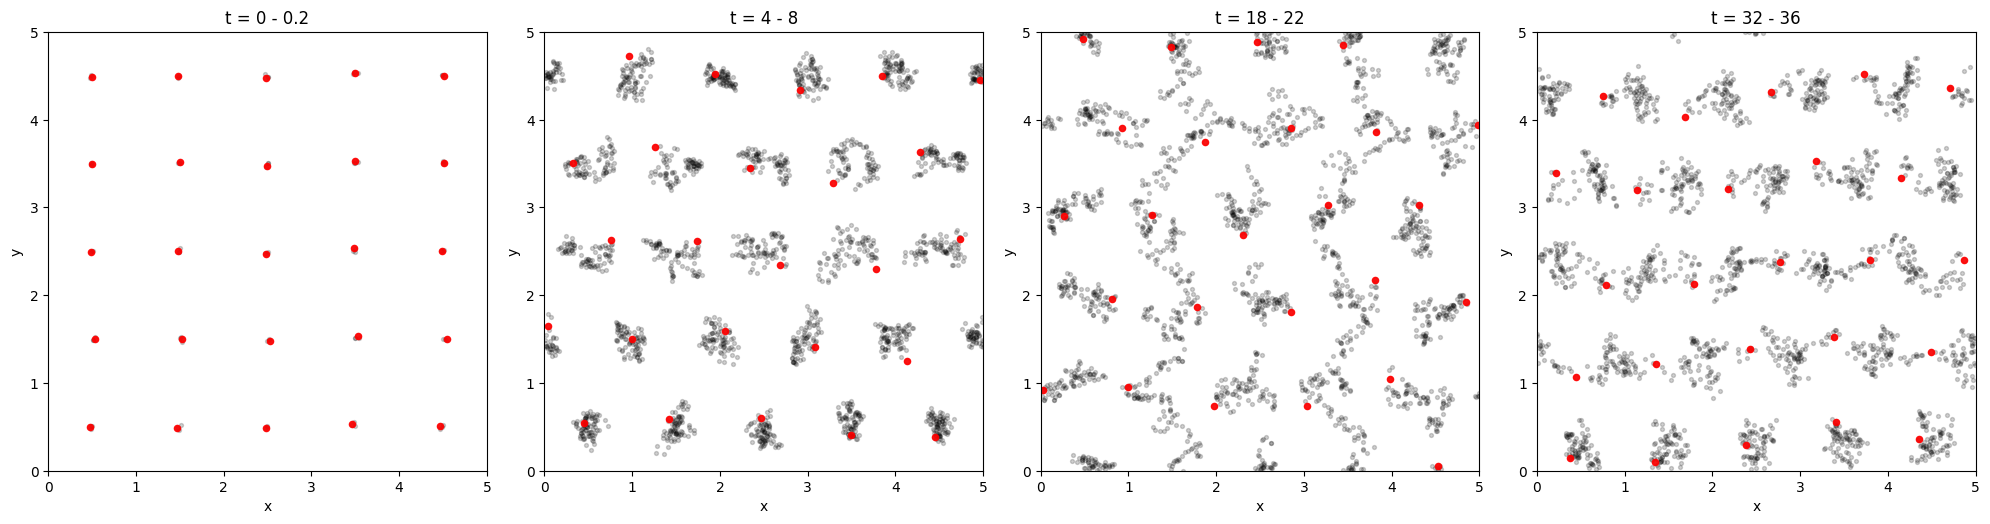

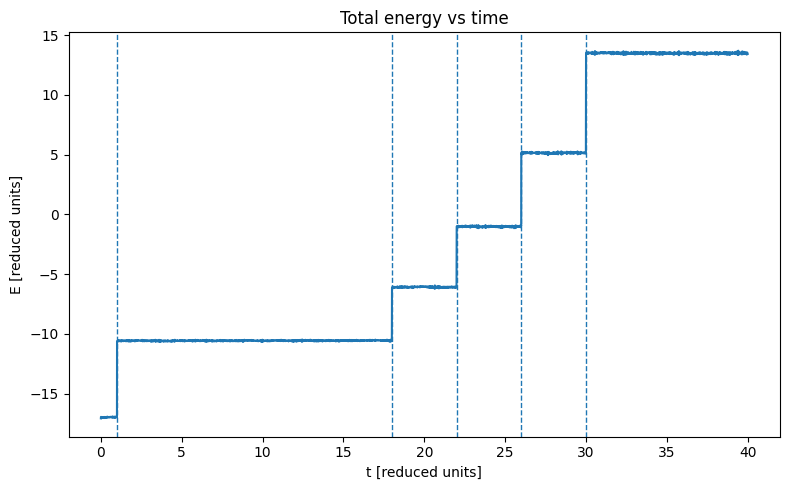

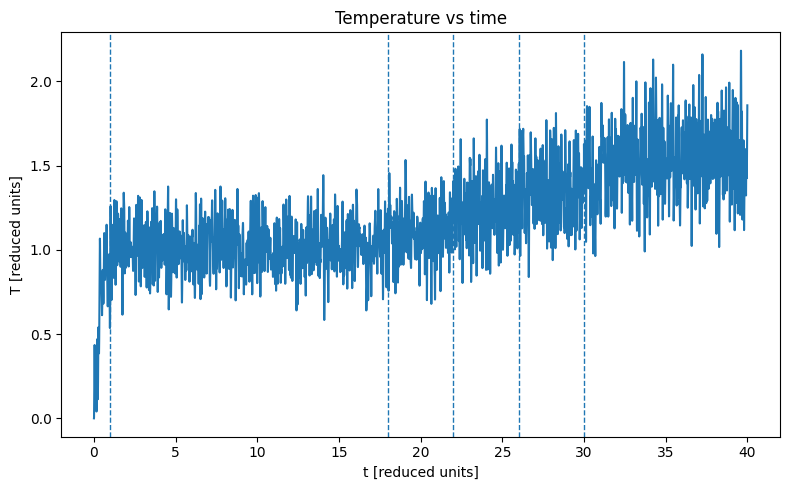

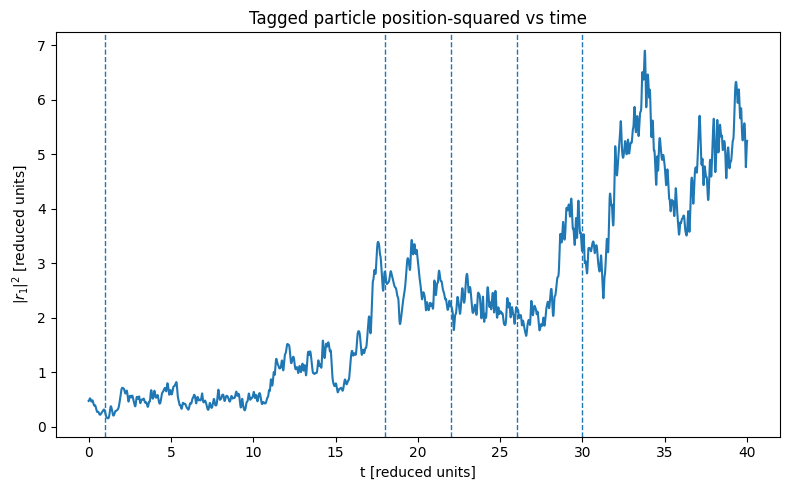

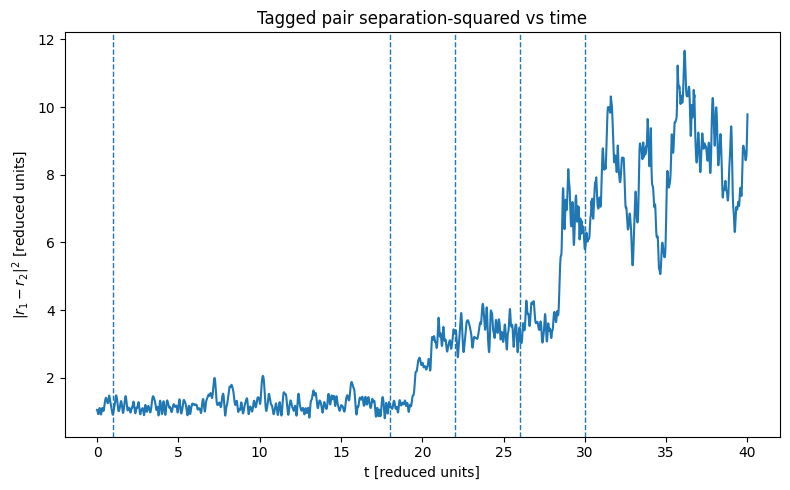

Heating events applied:
  t = 1.000, velocity scale factor = 1.150
  t = 18.000, velocity scale factor = 1.080
  t = 22.000, velocity scale factor = 1.080
  t = 26.000, velocity scale factor = 1.100
  t = 30.000, velocity scale factor = 1.120

Final time = 40.000
Initial energy = -17.070519
Final energy   = 13.422586
Mean temperature = 1.206512
Final tagged pair separation^2 = 9.783378


In [ ]:
# Lab 12 - Task 2

import numpy as np;
import matplotlib.pyplot as plt;

# Parameters
N = 25;
L = 5.0;
dt = 0.005;
tmax = 40.0;
rcut = 3.0;
dmax = 0.05;
record_every = 10;
rng = np.random.default_rng(12345);

# Snapshot windows:early relaxation, solid-like regime, melting regime, late hot regime
snapshot_windows = [(0.0, 0.2), (4.0, 8.0), (18.0, 22.0), (32.0, 36.0),];

# Heating schedule strat - mild kick early to speed equilibration, let system settle then staged heating to melt
heating_events = [(1.0, 1.15),   # mild early heating: speeds relaxation
    (18.0, 1.08),  # begin melting protocol
    (22.0, 1.08),
    (26.0, 1.10),
    (30.0, 1.12),];


# Helper functions
def wrap_positions(r, L):
    return r % L;

def minimum_image(dx, L):
    return dx - L * np.round(dx / L);

def pair_displacement_wrapped(ri_wrap, rj_wrap, L):
    dx = minimum_image(ri_wrap[0] - rj_wrap[0], L);
    dy = minimum_image(ri_wrap[1] - rj_wrap[1], L);
    return dx, dy;

def initialize_system(N, L, dmax, rng):
    r = np.zeros((N, 2), dtype = float);
    rprev = np.zeros((N, 2), dtype = float);
    Ngrid = int(np.ceil(np.sqrt(N)));
    Lgrid = L / Ngrid;

    for k in range(N):
        i = k // Ngrid;
        j = k % Ngrid;
        r[k, 0] = (i + 0.5) * Lgrid + (rng.random() - 0.5) * dmax * Lgrid * np.sqrt(2.0);
        r[k, 1] = (j + 0.5) * Lgrid + (rng.random() - 0.5) * dmax * Lgrid * np.sqrt(2.0);
    #endfor
    # initially at rest
    rprev[:] = r;
    return r, rprev;

def compute_forces_from_wrapped(r_wrap, N, L, rcut):
    F = np.zeros((N, 2), dtype = float);
    rcut2 = rcut * rcut;

    for i in range(N):
        for j in range(i):
            dx, dy = pair_displacement_wrapped(r_wrap[i], r_wrap[j], L);
            rij2 = dx * dx + dy * dy;
            if rij2 == 0.0 or rij2 > rcut2:
                continue;

            invr2 = 1.0 / rij2;
            invr6 = invr2 ** 3;
            invr8 = invr6 * invr2;
            invr14 = invr8 * invr6;
            coeff = 48.0 * invr14 - 24.0 * invr8;

            fx = coeff * dx;
            fy = coeff * dy;

            F[i, 0] += fx;
            F[i, 1] += fy;
            F[j, 0] -= fx;
            F[j, 1] -= fy;

    return F;

def verlet_step_unwrapped(r_unwrap, rprev_unwrap, N, L, dt, rcut):
    r_wrap = wrap_positions(r_unwrap, L);
    F = compute_forces_from_wrapped(r_wrap, N, L, rcut);
    rnew_unwrap = 2.0 * r_unwrap - rprev_unwrap + (dt ** 2) * F;
    v_now = (rnew_unwrap - rprev_unwrap) / (2.0 * dt);

    return rnew_unwrap, r_unwrap.copy(), v_now;

def calculate_energy_temperature(r_unwrap, v, N, L, rcut):
    Ekin = 0.5 * np.sum(v[:, 0] ** 2 + v[:, 1] ** 2);
    r_wrap = wrap_positions(r_unwrap, L);
    Epot = 0.0;
    rcut2 = rcut * rcut;

    for i in range(N):
        for j in range(i):
            dx, dy = pair_displacement_wrapped(r_wrap[i], r_wrap[j], L);
            rij2 = dx * dx + dy * dy;
            if rij2 == 0.0 or rij2 > rcut2:
                continue;

            invr6 = 1.0 / (rij2 ** 3);
            invr12 = invr6 * invr6;
            Epot += 4.0 * (invr12 - invr6);

    Etot = Ekin + Epot;
    T = Ekin / N;
    return Etot, T;

def tagged_observables(r_unwrap, L):
    # tagged particle uses unwrapped position
    r1sq = r_unwrap[0, 0] ** 2 + r_unwrap[0, 1] ** 2
    # tagged pair uses periodic minimum-image separation
    r_wrap = wrap_positions(r_unwrap, L);
    dx12, dy12 = pair_displacement_wrapped(r_wrap[0], r_wrap[1], L);
    r12sq = dx12 ** 2 + dy12 ** 2;

    return r1sq, r12sq;

# Rescale previous position relative to current one to rescale velocity without changing the current position.
def apply_velocity_scale(r_unwrap, rprev_unwrap, scale):
    return r_unwrap - scale * (r_unwrap - rprev_unwrap);


# Run
r_unwrap, rprev_unwrap = initialize_system(N, L, dmax, rng);
nsteps = int(round(tmax / dt));
times = [];
energies = [];
temps = [];
r1sq_list = [];
r12sq_list = [];
snapshot_tracks = {w: [] for w in snapshot_windows};
heating_log = [];
event_index = 0;

# initial values
t = 0.0;
v = np.zeros((N, 2), dtype = float);
E, T = calculate_energy_temperature(r_unwrap, v, N, L, rcut);
r1sq, r12sq = tagged_observables(r_unwrap, L);

times.append(t);
energies.append(E);
temps.append(T);
r1sq_list.append(r1sq);
r12sq_list.append(r12sq);

for step in range(1, nsteps + 1):
    t_next = step * dt;

    # apply scheduled heating when the target time is reached
    while event_index < len(heating_events) and t_next >= heating_events[event_index][0]:
        event_time, scale = heating_events[event_index];
        rprev_unwrap = apply_velocity_scale(r_unwrap, rprev_unwrap, scale);
        heating_log.append((event_time, scale));
        event_index += 1;

    rnew_unwrap, rold_unwrap, v = verlet_step_unwrapped(r_unwrap, rprev_unwrap, N, L, dt, rcut);
    rprev_unwrap = rold_unwrap;
    r_unwrap = rnew_unwrap;
    t = t_next;

    E, T = calculate_energy_temperature(rold_unwrap, v, N, L, rcut);
    r1sq, r12sq = tagged_observables(rold_unwrap, L);

    times.append(t);
    energies.append(E);
    temps.append(T);
    r1sq_list.append(r1sq);
    r12sq_list.append(r12sq);

    if step % record_every == 0:
        r_plot = wrap_positions(rold_unwrap, L);
        for w in snapshot_windows:
            t1, t2 = w;
            if t1 <= t <= t2:
                snapshot_tracks[w].append(r_plot.copy());

times = np.array(times);
energies = np.array(energies);
temps = np.array(temps);
r1sq_list = np.array(r1sq_list);
r12sq_list = np.array(r12sq_list);


# Snapshot figure
fig, axes = plt.subplots(1, len(snapshot_windows), figsize=(5 * len(snapshot_windows), 5));
if len(snapshot_windows) == 1:
    axes = [axes];

for ax, w in zip(axes, snapshot_windows):
    tracks = snapshot_tracks[w];
    t1, t2 = w;
    for frame in tracks:
        ax.scatter(frame[:, 0], frame[:, 1], s = 8, color = 'black', alpha = 0.18);
    #endfor

    if len(tracks) > 0:
        last = tracks[-1];
        ax.scatter(last[:, 0], last[:, 1], s = 20, color = 'red', alpha = 0.9);

    ax.set_xlim(0, L);
    ax.set_ylim(0, L);
    ax.set_aspect('equal');
    ax.set_xlabel('x');
    ax.set_ylabel('y');
    ax.set_title(f't = {t1:g} - {t2:g}');
#endfor
plt.tight_layout();
plt.show();


# Time series plots
def add_event_lines(ax, heating_events):
    for te, _ in heating_events:
        ax.axvline(te, linestyle = '--', linewidth = 1);
    #endfor

plt.figure(figsize = (8, 5));
plt.plot(times, energies, lw = 1.5);
add_event_lines(plt.gca(), heating_events);
plt.xlabel('t [reduced units]');
plt.ylabel('E [reduced units]');
plt.title('Total energy vs time');
plt.tight_layout();
plt.show();

plt.figure(figsize = (8, 5));
plt.plot(times, temps, lw = 1.5);
add_event_lines(plt.gca(), heating_events);
plt.xlabel('t [reduced units]');
plt.ylabel('T [reduced units]');
plt.title('Temperature vs time');
plt.tight_layout();
plt.show();

plt.figure(figsize = (8, 5));
plt.plot(times, r1sq_list, lw = 1.5);
add_event_lines(plt.gca(), heating_events);
plt.xlabel('t [reduced units]');
plt.ylabel(r'$|r_1|^2$ [reduced units]');
plt.title('Tagged particle position-squared vs time');
plt.tight_layout();
plt.show();

plt.figure(figsize = (8, 5));
plt.plot(times, r12sq_list, lw = 1.5);
add_event_lines(plt.gca(), heating_events);
plt.xlabel('t [reduced units]');
plt.ylabel(r'$|r_1-r_2|^2$ [reduced units]');
plt.title('Tagged pair separation-squared vs time');
plt.tight_layout();
plt.show();


# Summary
print("Heating events applied:");
for te, scale in heating_log:
    print(f"  t = {te:.3f}, velocity scale factor = {scale:.3f}");
#endfor
print()
print(f"Final time = {times[-1]:.3f}");
print(f"Initial energy = {energies[0]:.6f}");
print(f"Final energy   = {energies[-1]:.6f}");
print(f"Mean temperature = {temps.mean():.6f}");
print(f"Final tagged pair separation^2 = {r12sq_list[-1]:.6f}");

# EOF

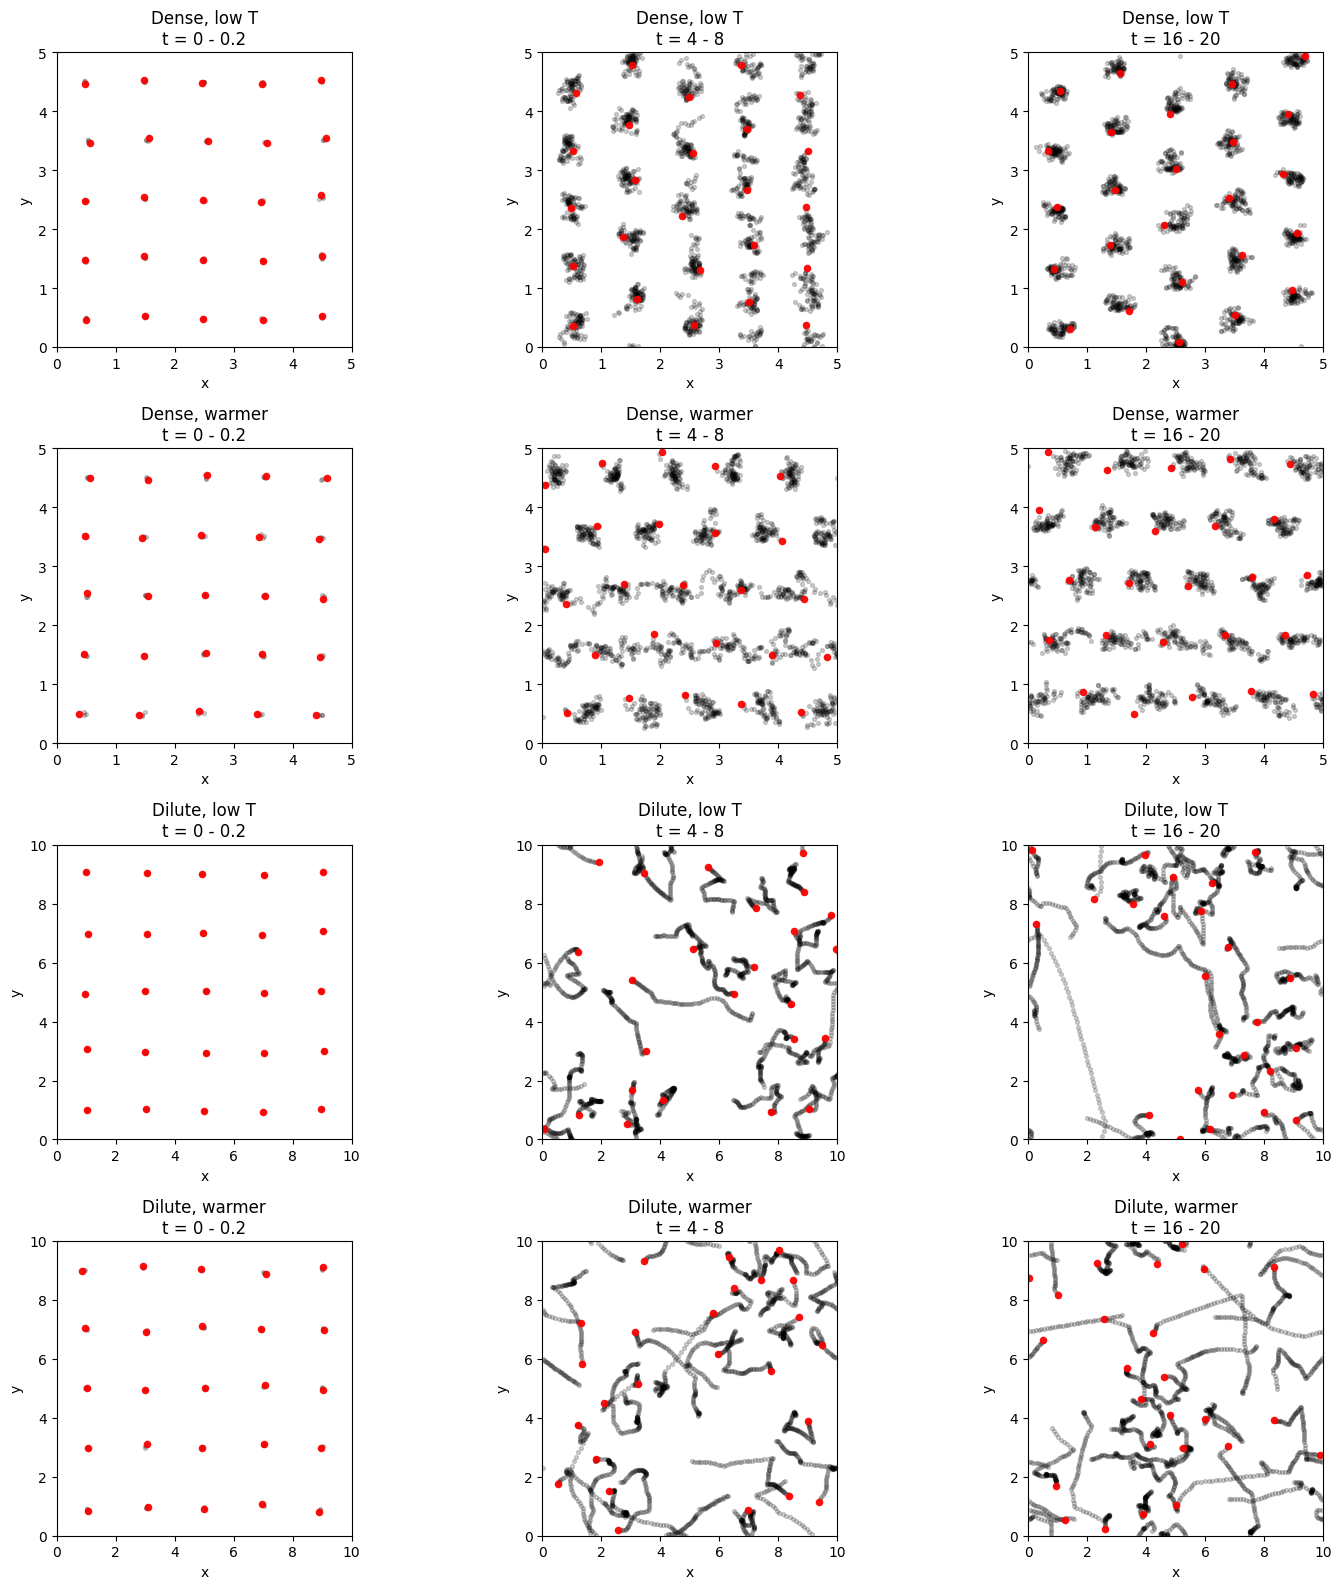

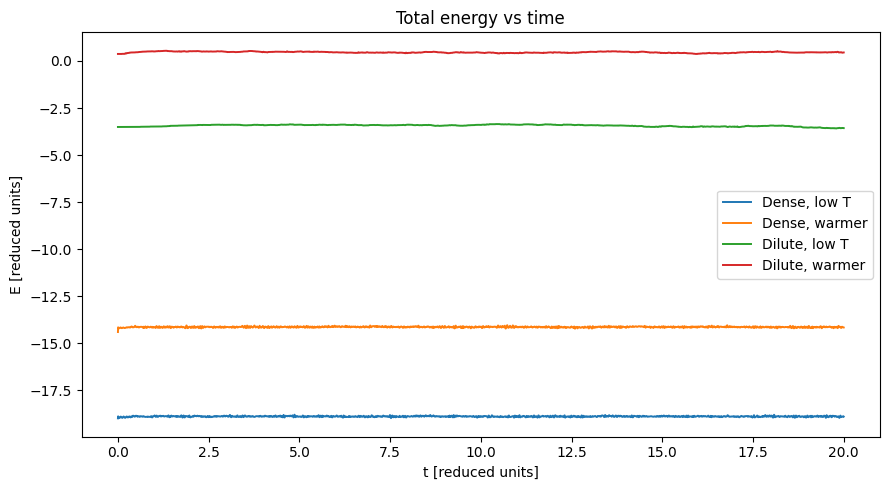

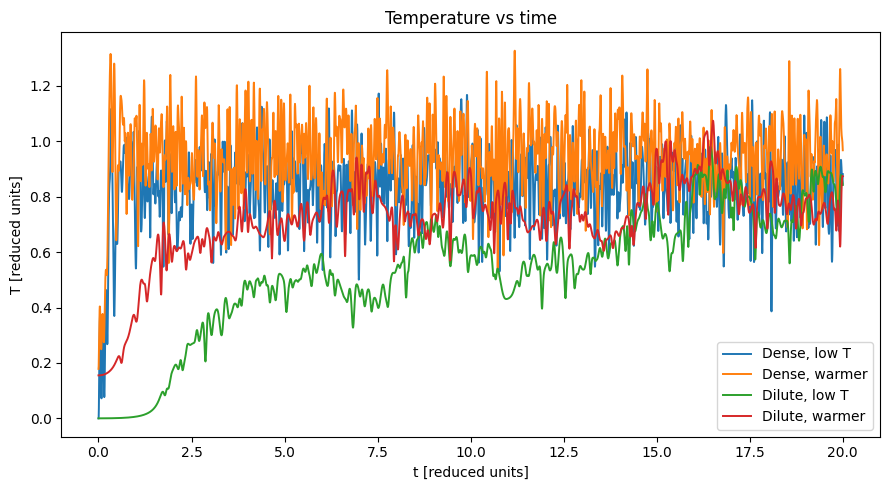

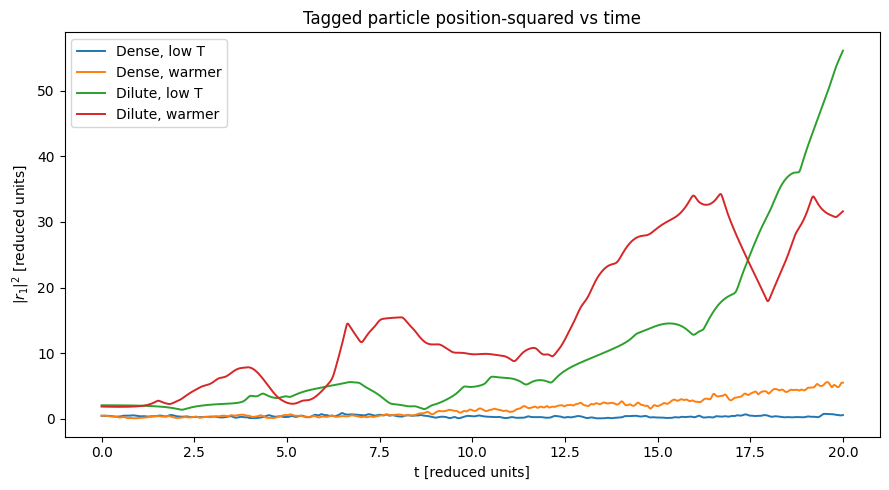

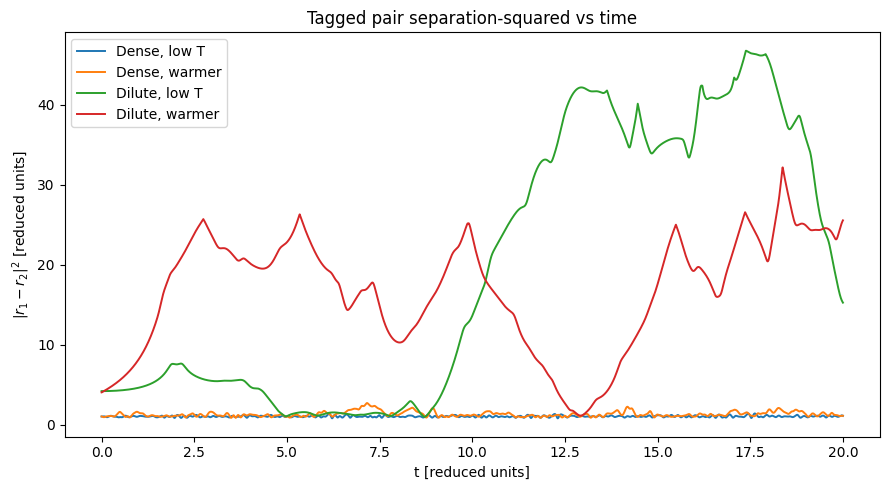

Case summaries:

Dense, low T:
  L = 5.0, v0max = 0.00
  Initial energy = -18.988409
  Final energy   = -18.896396
  Mean temperature = 0.837364
  Final tagged pair separation^2 = 1.087806

Dense, warmer:
  L = 5.0, v0max = 1.00
  Initial energy = -14.401708
  Final energy   = -14.159761
  Mean temperature = 0.946738
  Final tagged pair separation^2 = 1.101416

Dilute, low T:
  L = 10.0, v0max = 0.00
  Initial energy = -3.505914
  Final energy   = -3.567312
  Mean temperature = 0.530592
  Final tagged pair separation^2 = 15.252860

Dilute, warmer:
  L = 10.0, v0max = 1.00
  Initial energy = 0.374842
  Final energy   = 0.453281
  Mean temperature = 0.718287
  Final tagged pair separation^2 = 25.549290



In [ ]:
# Lab 12 - Task 3

import numpy as np;
import matplotlib.pyplot as plt;

# Global parameter
N = 25;
dt = 0.005;
tmax = 20.0;
rcut = 3.0
dmax = 0.05
record_every = 10;
rng_master = np.random.default_rng(12345);

# Cases to compare
cases = [{"label": "Dense, low T",    "L": 5.0,  "v0max": 0.0}, {"label": "Dense, warmer",   "L": 5.0,  "v0max": 1.0},
 {"label": "Dilute, low T",   "L": 10.0, "v0max": 0.0}, {"label": "Dilute, warmer",  "L": 10.0, "v0max": 1.0},];
snapshot_windows = [(0.0, 0.2), (4.0, 8.0), (16.0, 20.0)];


# Helpers

def wrap_positions(r, L):
    return r % L;

def minimum_image(dx, L):
    return dx - L * np.round(dx / L);

def pair_displacement_wrapped(ri_wrap, rj_wrap, L):
    dx = minimum_image(ri_wrap[0] - rj_wrap[0], L);
    dy = minimum_image(ri_wrap[1] - rj_wrap[1], L);
    return dx, dy;

def initialize_system(N, L, dmax, v0max, rng, dt):
    r = np.zeros((N, 2), dtype = float);
    rprev = np.zeros((N, 2), dtype = float);
    v0 = np.zeros((N, 2), dtype = float);
    Ngrid = int(np.ceil(np.sqrt(N)));
    Lgrid = L / Ngrid;

    for k in range(N):
        i = k // Ngrid;
        j = k % Ngrid;

        r[k, 0] = (i + 0.5) * Lgrid + (rng.random() - 0.5) * dmax * Lgrid * np.sqrt(2.0);
        r[k, 1] = (j + 0.5) * Lgrid + (rng.random() - 0.5) * dmax * Lgrid * np.sqrt(2.0);

        v0[k, 0] = v0max * (rng.random() - 0.5) * np.sqrt(2.0);
        v0[k, 1] = v0max * (rng.random() - 0.5) * np.sqrt(2.0);
    #endfor

    # previous position from initial velocity
    rprev[:] = r - v0 * dt;
    return r, rprev, v0;

def compute_forces_from_wrapped(r_wrap, N, L, rcut):
    F = np.zeros((N, 2), dtype = float);
    rcut2 = rcut * rcut;

    for i in range(N):
        for j in range(i):
            dx, dy = pair_displacement_wrapped(r_wrap[i], r_wrap[j], L);
            rij2 = dx * dx + dy * dy;
            if rij2 == 0.0 or rij2 > rcut2:
                continue;

            invr2 = 1.0 / rij2;
            invr6 = invr2 ** 3;
            invr8 = invr6 * invr2;
            invr14 = invr8 * invr6;
            coeff = 48.0 * invr14 - 24.0 * invr8;

            fx = coeff * dx;
            fy = coeff * dy;
            F[i, 0] += fx;
            F[i, 1] += fy;
            F[j, 0] -= fx;
            F[j, 1] -= fy;
        #endfor
    #endfor
    return F;

def verlet_step_unwrapped(r_unwrap, rprev_unwrap, N, L, dt, rcut):
    r_wrap = wrap_positions(r_unwrap, L);
    F = compute_forces_from_wrapped(r_wrap, N, L, rcut);
    rnew_unwrap = 2.0 * r_unwrap - rprev_unwrap + (dt ** 2) * F;
    v_now = (rnew_unwrap - rprev_unwrap) / (2.0 * dt);

    return rnew_unwrap, r_unwrap.copy(), v_now;

def calculate_energy_temperature(r_unwrap, v, N, L, rcut):
    Ekin = 0.5 * np.sum(v[:, 0] ** 2 + v[:, 1] ** 2);
    r_wrap = wrap_positions(r_unwrap, L);
    Epot = 0.0;
    rcut2 = rcut * rcut;

    for i in range(N):
        for j in range(i):
            dx, dy = pair_displacement_wrapped(r_wrap[i], r_wrap[j], L);
            rij2 = dx * dx + dy * dy;
            if rij2 == 0.0 or rij2 > rcut2:
                continue;

            invr6 = 1.0 / (rij2 ** 3);
            invr12 = invr6 * invr6;
            Epot += 4.0 * (invr12 - invr6);
        #endfor
    #endfor

    Etot = Ekin + Epot;
    T = Ekin / N;
    return Etot, T;

def tagged_observables(r_unwrap, L):
    r1sq = r_unwrap[0, 0] ** 2 + r_unwrap[0, 1] ** 2;
    r_wrap = wrap_positions(r_unwrap, L);
    dx12, dy12 = pair_displacement_wrapped(r_wrap[0], r_wrap[1], L);
    r12sq = dx12 ** 2 + dy12 ** 2;
    return r1sq, r12sq;

def run_case(case, case_seed):
    rng = np.random.default_rng(case_seed);
    L = case["L"];
    v0max = case["v0max"];
    r_unwrap, rprev_unwrap, v = initialize_system(N, L, dmax, v0max, rng, dt);
    nsteps = int(round(tmax / dt));

    times, energies, temps, r1sq_list, r12sq_list = [], [], [], [], [];
    snapshot_tracks = {w: [] for w in snapshot_windows};

    t = 0.0;
    E, T = calculate_energy_temperature(r_unwrap, v, N, L, rcut);
    r1sq, r12sq = tagged_observables(r_unwrap, L);

    times.append(t);
    energies.append(E);
    temps.append(T);
    r1sq_list.append(r1sq);
    r12sq_list.append(r12sq);

    for step in range(1, nsteps + 1):
        rnew_unwrap, rold_unwrap, v = verlet_step_unwrapped(r_unwrap, rprev_unwrap, N, L, dt, rcut);
        rprev_unwrap = rold_unwrap;
        r_unwrap = rnew_unwrap;
        t = step * dt;

        E, T = calculate_energy_temperature(rold_unwrap, v, N, L, rcut);
        r1sq, r12sq = tagged_observables(rold_unwrap, L);

        times.append(t);
        energies.append(E);
        temps.append(T);
        r1sq_list.append(r1sq);
        r12sq_list.append(r12sq);

        if step % record_every == 0:
            r_plot = wrap_positions(rold_unwrap, L);
            for w in snapshot_windows:
                t1, t2 = w;
                if t1 <= t <= t2:
                    snapshot_tracks[w].append(r_plot.copy());
            #endfor
    #endfor
    return {"label": case["label"], "L": L, "v0max": v0max, "times": np.array(times), "energies": np.array(energies), "temps": np.array(temps),
        "r1sq": np.array(r1sq_list), "r12sq": np.array(r12sq_list), "snapshots": snapshot_tracks,};

# Run all cases
results = [];
for idx, case in enumerate(cases):
    results.append(run_case(case, case_seed = 12345 + 100*idx));
#endfor

# Snapshots figure: one row per case, one col per window
fig, axes = plt.subplots(len(results), len(snapshot_windows), figsize=(5 * len(snapshot_windows), 4 * len(results)));
if len(results) == 1:
    axes = np.array([axes]);

for i, res in enumerate(results):
    for j, w in enumerate(snapshot_windows):
        ax = axes[i, j];
        tracks = res["snapshots"][w];
        t1, t2 = w;

        for frame in tracks:
            ax.scatter(frame[:, 0], frame[:, 1], s = 8, color = 'black', alpha = 0.18);

        if len(tracks) > 0:
            last = tracks[-1];
            ax.scatter(last[:, 0], last[:, 1], s = 20, color = 'red', alpha = 0.9);

        ax.set_xlim(0, res["L"]);
        ax.set_ylim(0, res["L"]);
        ax.set_aspect('equal');
        ax.set_xlabel("x");
        ax.set_ylabel("y");
        ax.set_title(f"{res['label']}\nt = {t1:g} - {t2:g}");
    #endfor
#endfor
plt.tight_layout();
plt.show();


# Comparison time series
def plot_comparison(key, ylabel, title):
    plt.figure(figsize = x(9, 5));
    for res in results:
        plt.plot(res["times"], res[key], lw = 1.4, label = res["label"]);
    #endfor
    plt.xlabel("t [reduced units]");
    plt.ylabel(ylabel);
    plt.title(title);
    plt.legend();
    plt.tight_layout();
    plt.show();

plot_comparison("energies", "E [reduced units]", "Total energy vs time");
plot_comparison("temps", "T [reduced units]", "Temperature vs time");
plot_comparison("r1sq", r"$|r_1|^2$ [reduced units]", "Tagged particle position-squared vs time");
plot_comparison("r12sq", r"$|r_1-r_2|^2$ [reduced units]", "Tagged pair separation-squared vs time");


# Numerical summary
print("Case summaries:\n");
for res in results:
    print(f"{res['label']}:");
    print(f"  L = {res['L']:.1f}, v0max = {res['v0max']:.2f}");
    print(f"  Initial energy = {res['energies'][0]:.6f}");
    print(f"  Final energy   = {res['energies'][-1]:.6f}");
    print(f"  Mean temperature = {res['temps'].mean():.6f}");
    print(f"  Final tagged pair separation^2 = {res['r12sq'][-1]:.6f}");
    print();
#endfor


# EOF

